# Dataset Exploration and Audit - Twitter Bot Detection

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import ast
import json

from tqdm import tqdm
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [110]:
DATA_PATH = "../data"
FILES = {
    "labeled_users":
    os.path.join(
        DATA_PATH,
        "1000user_sheet - 1k_users.csv"
    ),

    "unlabeled_users":
    os.path.join(
        DATA_PATH,
        "all_users_new - 19k.csv"
    ),

    "followers_graph":
    os.path.join(
        DATA_PATH,
        "all_users_new - follower_following.csv"
    ),

    "tweets":
    os.path.join(
        DATA_PATH,
        "1000user_sheet - tweets_meta_data.csv"
    )
}


FILES

{'labeled_users': '../data\\1000user_sheet - 1k_users.csv',
 'unlabeled_users': '../data\\all_users_new - 19k.csv',
 'followers_graph': '../data\\all_users_new - follower_following.csv',
 'tweets': '../data\\1000user_sheet - tweets_meta_data.csv'}

In [111]:
users_1k = pd.read_csv(
    FILES["labeled_users"]
)

users_19k = pd.read_csv(
    FILES["unlabeled_users"]
)

graph_df = pd.read_csv(
    FILES["followers_graph"]
)

tweets_df = pd.read_csv(
    FILES["tweets"]
)

print("Labeled users:", users_1k.shape)
print("Unlabeled users:", users_19k.shape)
print("Graph:", graph_df.shape)
print("Tweets:", tweets_df.shape)

Labeled users: (1103, 101)
Unlabeled users: (19510, 75)
Graph: (3453, 4)
Tweets: (75913, 38)


In [112]:
datasets = {
    "1K Users":users_1k,
    "19K Users":users_19k,
    "Graph":graph_df,
    "Tweets":tweets_df
}

for name,df in datasets.items():
    print("="*60)
    print(name)
    print("="*60)
    print(
        "Rows:",
        df.shape[0]
    )
    print(
        "Columns:",
        df.shape[1]
    )
    print()

1K Users
Rows: 1103
Columns: 101

19K Users
Rows: 19510
Columns: 75

Graph
Rows: 3453
Columns: 4

Tweets
Rows: 75913
Columns: 38



In [113]:
for name,df in datasets.items():
    print("\n", "="*50)
    print(name)
    print("="*50)
    display(
        pd.DataFrame(
            {
            "column":df.columns,
            "dtype":df.dtypes.values
            }
        )
    )


1K Users


,column,dtype
0,id,float64
1,screen_name,str
2,following,float64
3,created_at,str
4,default_profile,bool
...,...,...
96,ارسال تعداد پست زیاد در روز ایجاد حساب,int64
97,ارسال تعداد پست زیاد در هفته ایجاد حساب,int64
98,نداشتن گفت و گو با بقیه کاربران ( گذاشتن ریپلا...,int64
99,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,float64



19K Users


,column,dtype
0,id,float64
1,cluster_id,float64
2,screen_name,str
3,name,str
4,clean_description,str
...,...,...
70,statuses_count,float64
71,translator_type,str
72,want_retweets,object
73,last_updated,str



Graph


,column,dtype
0,id,float64
1,screen_name,str
2,followers,str
3,following,str



Tweets


,column,dtype
0,id,float64
1,screen_name,str
2,text,str
3,hashtags,str
4,user.followers,int64
5,user.following,int64
6,user.post,int64
7,bookmark_count,int64
8,published_at,str
9,conversation_id,float64


In [114]:
for name,df in datasets.items():
    print(
        name,
        "duplicates:",
        df.duplicated().sum()
    )

1K Users duplicates: 0
19K Users duplicates: 0
Graph duplicates: 0
Tweets duplicates: 0


In [115]:
def missing_report(df,name):
    missing = (
        df.isnull()
        .sum()
        .sort_values(
            ascending=False
        )
    )
    report = pd.DataFrame({
        "missing_count":missing,
        "percentage":
        missing/len(df)*100
    })
    print(name)
    display(
        report.head(30)
    )

for name,df in datasets.items():
    missing_report(df,name)

1K Users


,missing_count,percentage
Grok 4,1103,100.000000
Unnamed: 58,1103,100.000000
profile_interstitial_type,1102,99.909338
تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی حساب ها دارد),1101,99.818676
LLM(Gemini),1097,99.456029
verified_type,1096,99.365367
آیا دنبال‌شوندگان/دنبال‌کننده‌ها غیرعادی‌اند؟نسبت غیرمنطقی، فالوورهای فیک (ویژگی‌های شبکه‌ای و تعاملات (Network Features)\nالگوهای ارتباطی و شبکه اجتماعی حساب‌ها:\n• نسبت فالوورها به فالووینگ:\no دنبال‌کردن هزاران نفر و داشتن تعداد کمی فالوور.\no یا برعکس: داشتن تعداد زیاد فالوور اما بدون تعامل واقعی.\n• خوشه‌های هماهنگ: چند حساب با هم توییت مشابه منتشر می‌کنند یا همزمان لایک/ری‌توئیت می‌کنند.\n• شبکه‌های مشابه: داشتن مجموعه‌ای مشابه از فالوورها یا فالووینگ‌ها.\n• Retweet farms: حساب‌هایی که صرفاً ری‌توئیت می‌کنند تا ترند مصنوعی بسازند.),1091,98.912058
LLM(ChatGPT),1063,96.373527
"آیا پروفایل واقعی به‌نظر می‌رسد؟عکس واقعی، بیوگرافی کامل، نام کاربری (\n• نام کاربری(username/handle):\no وجود رشته‌های عددی طولانی (user12345678)\no شباهت زیاد نام‌ها در چند حساب مختلف مثلاً iran_news01, iran_news02، ….\no نام‌هایی بی‌معنی یا تصادفی (abc_45_klo)\n• تصویر پروفایل:\no استفاده از تصویر پیش‌فرض یا avatar عمومی\no تصاویر دزدیده‌شده یا تکراری می‌توان با جستجوی معکوس گوگل بررسی کرد.\no کیفیت پایین یا غیرمرتبط (مثلاً لوگوی تصادفی).\n• بیو (Bio):\no بیوهای خالی یا خیلی کوتاه.\no بیوهای تکراری بین چند حساب (کپی/پیست).\no استفاده از کلمات کلیدی مثل bot, feed, auto، یا فقط هشتگ.\n• تاریخ ایجاد حساب:\no حساب‌های خیلی جدید که در همان روز/هفته صدها توییت می‌زنند.\no موجی از حساب‌های جدید در بازه زمانی کوتاه.\n• لینک‌ها در پروفایل:\no لینک‌های کوتاه‌شده (tinyurl) که مقصدشان تبلیغی یا مشکوک است.\no تکرار یک دامنه در پروفایل چند حساب مشابه.)",1035,93.834995
"آیا تعامل با دیگران وجود دارد؟ریپلای، منشن، گفت‌وگو با کاربران (ویژگی‌های رفتاری در مکالمه (Conversational Features)\n• پاسخ‌دهی کم: حسابی که تقریباً هیچوقت جواب مستقیم نمی‌دهد.\n• پاسخ‌های ماشینی: جملات کلیشه‌ای و تکراری مثل ""Great post!"" یا ""Nice info""\n• تأخیر یکنواخت در پاسخ: مثلاً همیشه ۳ ثانیه بعد جواب می‌دهد.\n• نبود تعامل شخصی: اشاره نکردن به تجربیات فردی یا مکالمات واقعی.)",1034,93.744334


19K Users


,missing_count,percentage
Grok 4,19510,100.000000
reason 2,19510,100.000000
profile_interstitial_type,19505,99.974372
آیا دنبال‌شوندگان/دنبال‌کننده‌ها غیرعادی‌اند؟نسبت غیرمنطقی، فالوورهای فیک (ویژگی‌های شبکه‌ای و تعاملات (Network Features)\nالگوهای ارتباطی و شبکه اجتماعی حساب‌ها:\n• نسبت فالوورها به فالووینگ:\no دنبال‌کردن هزاران نفر و داشتن تعداد کمی فالوور.\no یا برعکس: داشتن تعداد زیاد فالوور اما بدون تعامل واقعی.\n• خوشه‌های هماهنگ: چند حساب با هم توییت مشابه منتشر می‌کنند یا همزمان لایک/ری‌توئیت می‌کنند.\n• شبکه‌های مشابه: داشتن مجموعه‌ای مشابه از فالوورها یا فالووینگ‌ها.\n• Retweet farms: حساب‌هایی که صرفاً ری‌توئیت می‌کنند تا ترند مصنوعی بسازند.),19430,99.589954
verified_type,19398,99.425935
LLM(Gemini),19343,99.144029
LLM(ChatGPT),19149,98.149667
tagger's name2,19009,97.432086
prob 2,19009,97.432086
"آیا پروفایل واقعی به‌نظر می‌رسد؟عکس واقعی، بیوگرافی کامل، نام کاربری (\n• نام کاربری(username/handle):\no وجود رشته‌های عددی طولانی (user12345678)\no شباهت زیاد نام‌ها در چند حساب مختلف مثلاً iran_news01, iran_news02، ….\no نام‌هایی بی‌معنی یا تصادفی (abc_45_klo)\n• تصویر پروفایل:\no استفاده از تصویر پیش‌فرض یا avatar عمومی\no تصاویر دزدیده‌شده یا تکراری می‌توان با جستجوی معکوس گوگل بررسی کرد.\no کیفیت پایین یا غیرمرتبط (مثلاً لوگوی تصادفی).\n• بیو (Bio):\no بیوهای خالی یا خیلی کوتاه.\no بیوهای تکراری بین چند حساب (کپی/پیست).\no استفاده از کلمات کلیدی مثل bot, feed, auto، یا فقط هشتگ.\n• تاریخ ایجاد حساب:\no حساب‌های خیلی جدید که در همان روز/هفته صدها توییت می‌زنند.\no موجی از حساب‌های جدید در بازه زمانی کوتاه.\n• لینک‌ها در پروفایل:\no لینک‌های کوتاه‌شده (tinyurl) که مقصدشان تبلیغی یا مشکوک است.\no تکرار یک دامنه در پروفایل چند حساب مشابه.)",18963,97.196310


Graph


,missing_count,percentage
screen_name,10,0.289603
id,0,0.000000
followers,0,0.000000
following,0,0.000000


Tweets


,missing_count,percentage
post_reply_match,75913,100.000000
has_graph,75896,99.977606
retweets_downloaded,75841,99.905155
has_embedding,75725,99.752348
replies_downloaded,75172,99.023883
is_real,71941,94.767695
last_update_fake,71909,94.725541
real_certainty,71734,94.495014
original.user_id,68713,90.515458
original.screen_name,68713,90.515458


In [116]:
users_1k["برچسب نهایی"].value_counts()

برچسب نهایی
human(2)         772
bot(1)           187
can’t find        58
unverified(4)     57
News Agent(3)     29
Name: count, dtype: int64

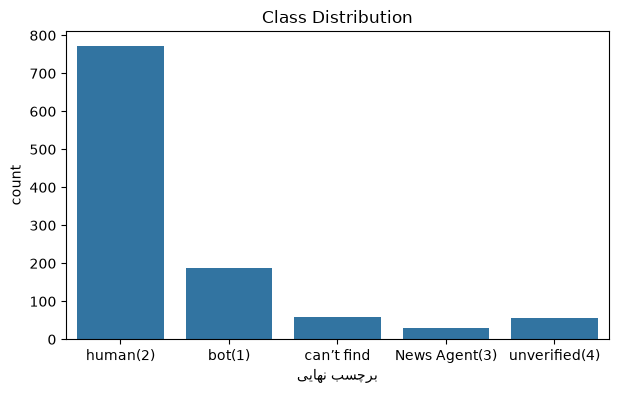

In [117]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=users_1k,
    x="برچسب نهایی"
)

plt.title(
    "Class Distribution"
)

plt.show()

In [118]:
profile_features = [
"followers_count",
"friends_count",
"statuses_count",
"favourites_count",
"listed_count",
"user_age"
]


users_1k[
profile_features
].describe()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,user_age
count,1.103000e+03,1103.000000,1103.000000,1103.000000,1103.000000,890.000000
mean,3.192274e+04,2807.503173,45048.220308,98469.411605,60.711695,2466.437079
std,1.377626e+05,4619.760170,61112.960490,117184.438263,202.261372,1600.423864
min,1.000000e+00,0.000000,29.000000,0.000000,0.000000,190.000000
25%,4.096500e+03,429.000000,10926.500000,24521.000000,4.000000,1075.000000
50%,6.647000e+03,1566.000000,25229.000000,59196.000000,10.000000,1907.000000
75%,1.484900e+04,3648.000000,54862.000000,130219.000000,30.500000,3684.250000
max,2.029889e+06,75710.000000,888076.000000,977712.000000,2775.000000,6586.000000


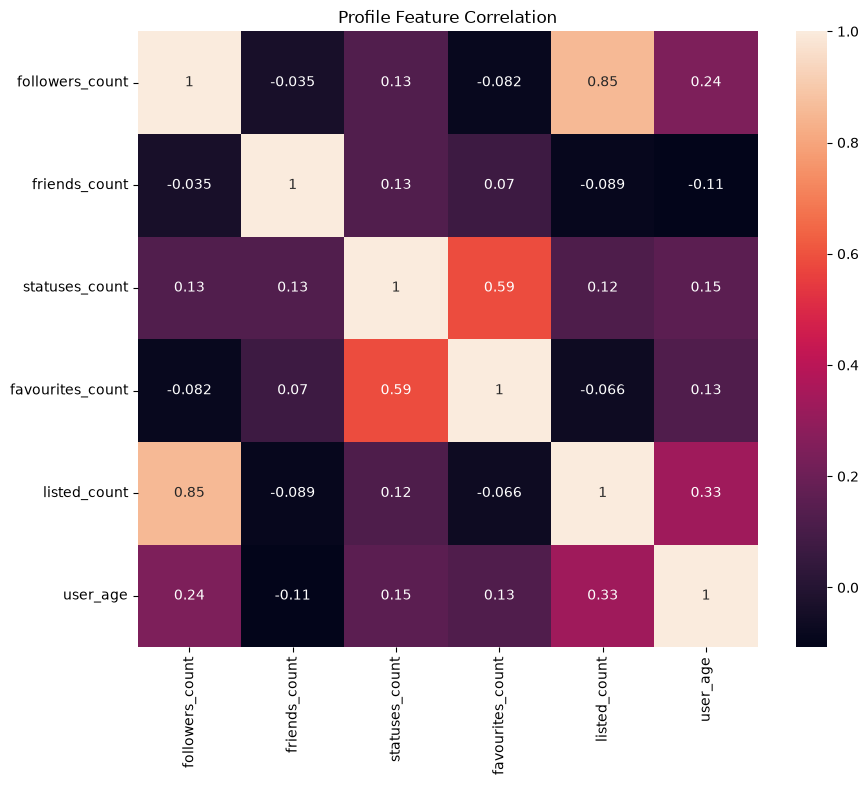

In [119]:
plt.figure(figsize=(10,8))
sns.heatmap(
    users_1k[
    profile_features
    ].corr(),
    annot=True
)

plt.title(
    "Profile Feature Correlation"
)

plt.show()

In [120]:
tweet_users = set(
    tweets_df["screen_name"]
)

user_names = set(
    users_1k["screen_name"]
)

coverage = (
len(tweet_users.intersection(user_names))/len(user_names))


print(
"Tweet Coverage:",
coverage*100,
"%"
)

Tweet Coverage: 99.63735267452402 %


In [121]:
# Check ID data types and possible precision issue

for name, df in {
    "1K Users": users_1k,
    "19K Users": users_19k,
    "Graph": graph_df,
    "Tweets": tweets_df
}.items():
    
    print(f"{name:15s} -> id dtype: {df['id'].dtype}")

1K Users        -> id dtype: float64
19K Users       -> id dtype: float64
Graph           -> id dtype: float64
Tweets          -> id dtype: float64


### Important note about user IDs

Twitter/X IDs are very large integer identifiers. Loading them as `float64` may cause
loss of precision. Therefore, `screen_name` will be used as the primary key for
cross-dataset matching in the exploratory phase.

In later preprocessing stages, identifier columns should preferably be loaded as strings.

In [122]:
def screen_name_audit(df, name):
    
    if "screen_name" not in df.columns:
        return
    
    total = len(df)
    missing = df["screen_name"].isna().sum()
    unique = df["screen_name"].nunique(dropna=True)
    duplicated = df["screen_name"].duplicated(keep=False).sum()
    
    print("=" * 55)
    print(name)
    print("=" * 55)
    print("Rows:", total)
    print("Missing screen_name:", missing)
    print("Unique screen_name:", unique)
    print("Rows with duplicated screen_name:", duplicated)


screen_name_audit(users_1k, "1K Users")
screen_name_audit(users_19k, "19K Users")
screen_name_audit(graph_df, "Graph")
screen_name_audit(tweets_df, "Tweets")

1K Users
Rows: 1103
Missing screen_name: 0
Unique screen_name: 1103
Rows with duplicated screen_name: 0
19K Users
Rows: 19510
Missing screen_name: 75
Unique screen_name: 19435
Rows with duplicated screen_name: 75
Graph
Rows: 3453
Missing screen_name: 10
Unique screen_name: 3359
Rows with duplicated screen_name: 171
Tweets
Rows: 75913
Missing screen_name: 0
Unique screen_name: 1099
Rows with duplicated screen_name: 75644


In [123]:
LABEL_COL = "برچسب نهایی"

class_counts = users_1k[LABEL_COL].value_counts(dropna=False)

class_report = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(users_1k) * 100
})

display(class_report.round(2))

,count,percentage
برچسب نهایی,,
human(2),772,69.99
bot(1),187,16.95
can’t find,58,5.26
unverified(4),57,5.17
News Agent(3),29,2.63


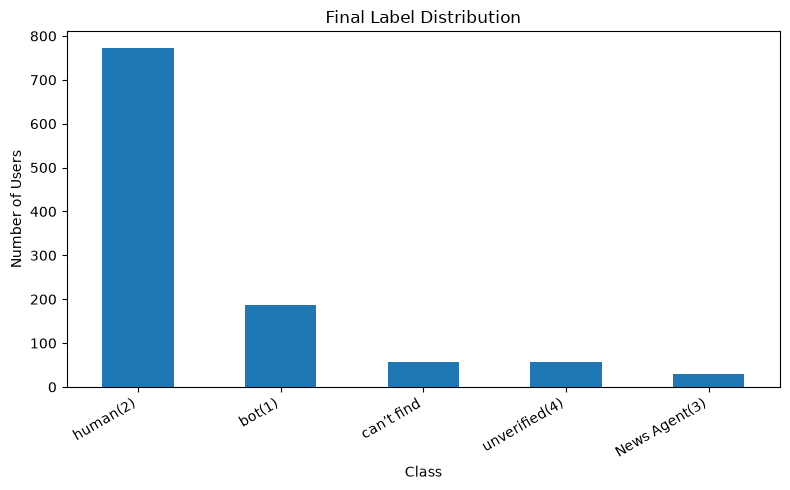

In [124]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Final Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Users")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [125]:
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print("Majority class:", class_counts.idxmax(), majority_count)
print("Minority class:", class_counts.idxmin(), minority_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class: human(2) 772
Minority class: News Agent(3) 29
Imbalance ratio: 26.62


In [126]:
tweet_count = (
    tweets_df
    .groupby("screen_name")
    .size()
    .rename("tweet_count")
    .reset_index()
)

display(tweet_count["tweet_count"].describe())

print("Users represented in tweet dataset:",
      tweet_count["screen_name"].nunique())

count    1099.000000
mean       69.074613
std       206.885795
min         1.000000
25%         2.000000
50%         7.000000
75%        46.000000
max      3439.000000
Name: tweet_count, dtype: float64

Users represented in tweet dataset: 1099


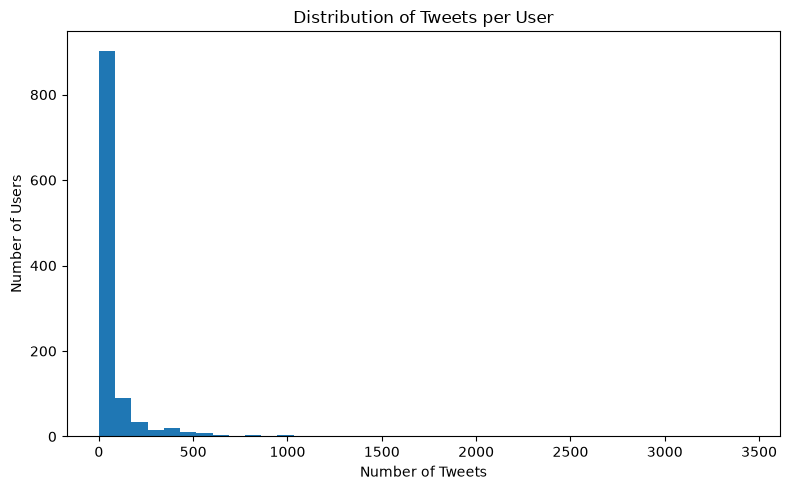

In [127]:
plt.figure(figsize=(8, 5))

plt.hist(
    tweet_count["tweet_count"],
    bins=40
)

plt.xlabel("Number of Tweets")
plt.ylabel("Number of Users")
plt.title("Distribution of Tweets per User")

plt.tight_layout()
plt.show()

In [128]:
labeled_names = set(
    users_1k["screen_name"].dropna().astype(str)
)

tweet_names = set(
    tweets_df["screen_name"].dropna().astype(str)
)

users_without_tweets = sorted(
    labeled_names - tweet_names
)

print("Labeled users:", len(labeled_names))
print("Labeled users with tweets:",
      len(labeled_names & tweet_names))

print("Labeled users WITHOUT tweets:",
      len(users_without_tweets))

display(
    pd.DataFrame(
        {"screen_name": users_without_tweets}
    )
)

Labeled users: 1103
Labeled users with tweets: 1099
Labeled users WITHOUT tweets: 4


,screen_name
0,Asayesh176
1,Javiiiid_97
2,Nazdooneh1376
3,Nazdooneh76


In [129]:
tweets_df["text_length_chars"] = (
    tweets_df["text"]
    .fillna("")
    .astype(str)
    .str.len()
)

tweets_df["text_length_words"] = (
    tweets_df["text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

display(
    tweets_df[
        ["text_length_chars", "text_length_words"]
    ].describe()
)

,text_length_chars,text_length_words
count,75913.000000,75913.000000
mean,160.479747,24.019799
std,156.431184,29.440116
min,1.000000,1.000000
25%,84.000000,9.000000
50%,133.000000,18.000000
75%,221.000000,35.000000
max,9597.000000,1956.000000


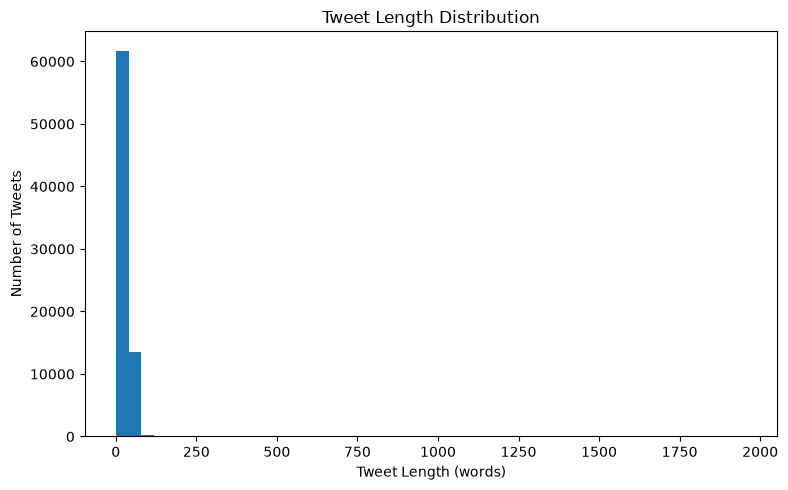

In [130]:
plt.figure(figsize=(8, 5))

plt.hist(
    tweets_df["text_length_words"],
    bins=50
)

plt.xlabel("Tweet Length (words)")
plt.ylabel("Number of Tweets")
plt.title("Tweet Length Distribution")

plt.tight_layout()
plt.show()

In [131]:
language_counts = (
    tweets_df["lang"]
    .fillna("missing")
    .value_counts()
)

language_report = pd.DataFrame({
    "count": language_counts,
    "percentage":
        language_counts / len(tweets_df) * 100
})

display(language_report.head(20).round(2))

,count,percentage
lang,,
fa,65016,85.65
en,4836,6.37
qme,3407,4.49
ar,1306,1.72
und,690,0.91
qht,185,0.24
in,91,0.12
de,77,0.10
ca,53,0.07


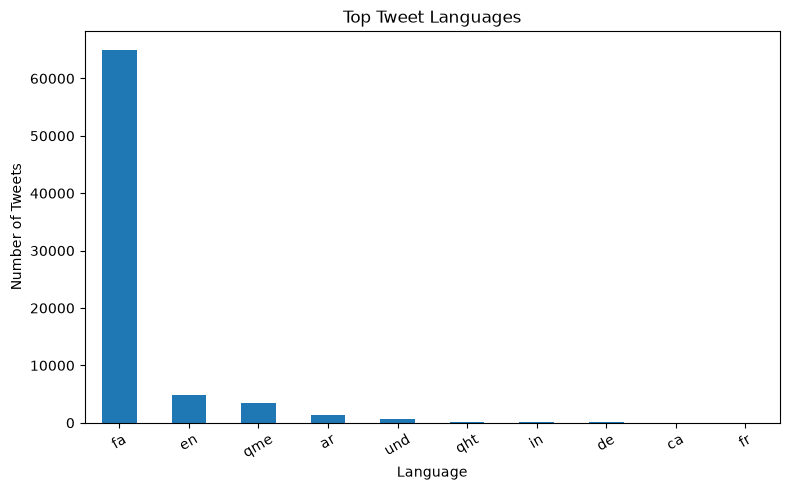

In [132]:
top_languages = language_counts.head(10)

plt.figure(figsize=(8, 5))

top_languages.plot(kind="bar")

plt.xlabel("Language")
plt.ylabel("Number of Tweets")
plt.title("Top Tweet Languages")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [133]:
tweet_type_report = pd.DataFrame({
    "count": tweets_df["type"].value_counts(dropna=False),
    "percentage":
        tweets_df["type"].value_counts(dropna=False)
        / len(tweets_df) * 100
})

display(tweet_type_report.round(2))

,count,percentage
type,,
tweet,45254,59.61
reply,22738,29.95
retweet_with_comment,7921,10.43


In [134]:
engagement_features = [
    "like_count",
    "reply_count",
    "retweet_count",
    "quote_count",
    "bookmark_count"
]

available_engagement = [
    c for c in engagement_features
    if c in tweets_df.columns
]

display(
    tweets_df[
        available_engagement
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
like_count,75913.0,328.739636,635.805533,0.0,10.0,143.0,360.0,29499.0
reply_count,75913.0,14.672941,46.384946,0.0,0.0,4.0,14.0,3859.0
retweet_count,75913.0,69.941947,117.255456,0.0,2.0,36.0,84.0,7021.0
quote_count,75913.0,2.181049,8.253312,0.0,0.0,1.0,2.0,875.0
bookmark_count,75913.0,2.903389,25.312733,0.0,0.0,0.0,2.0,5491.0


In [135]:
tweet_user_stats = (
    tweets_df
    .groupby("screen_name")
    .agg(
        tweet_count=("text", "size"),
        mean_like_count=("like_count", "mean"),
        mean_reply_count=("reply_count", "mean"),
        mean_retweet_count=("retweet_count", "mean"),
        mean_quote_count=("quote_count", "mean")
    )
    .reset_index()
)

display(tweet_user_stats.describe())

,tweet_count,mean_like_count,mean_reply_count,mean_retweet_count,mean_quote_count
count,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000
mean,69.074613,584.988480,55.112111,92.690740,8.764181
std,206.885795,1113.638023,157.636595,179.314262,33.063879
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,65.766667,3.000000,8.308176,0.503425
50%,7.000000,234.917415,10.538462,43.931034,1.866667
75%,46.000000,575.292727,31.000000,96.903766,4.818182
max,3439.000000,14372.500000,2328.000000,2666.000000,823.000000


In [136]:
hashtag_missing = tweets_df["hashtags"].isna().sum()
hashtag_available = len(tweets_df) - hashtag_missing

print("Tweets with hashtag information:", hashtag_available)
print("Tweets missing hashtag information:", hashtag_missing)
print(
    "Hashtag metadata coverage:",
    round(hashtag_available / len(tweets_df) * 100, 2),
    "%"
)

Tweets with hashtag information: 74599
Tweets missing hashtag information: 1314
Hashtag metadata coverage: 98.27 %


In [137]:
mention_available = tweets_df["user_mentions"].notna().sum()

print("Tweets with user_mentions:", mention_available)
print(
    "Percentage:",
    round(mention_available / len(tweets_df) * 100, 2),
    "%"
)

Tweets with user_mentions: 26723
Percentage: 35.2 %


In [138]:
temporal_behavior_features = [
    "tweet_frequency",
    "time_between_tweets",
    "min_tweets_per_hour",
    "min_tweets_per_day",
    "max_tweets_per_hour",
    "max_tweets_per_day",
    "max_occurence_of_same_gap",
    "mean_no_words",
    "mean_no_hashtags",
    "mean_favourites_per_tweet",
    "unique_mention_rate_per_tweet",
    "mean_user_mentions_per_tweet",
    "retweet_as_tweet_rate",
    "no_retweet_tweets",
    "mean_retweets_per_tweet"
]

available_temporal = [
    c for c in temporal_behavior_features
    if c in users_1k.columns
]

print("Available temporal/behavior features:")
print(available_temporal)

display(
    users_1k[available_temporal]
    .describe()
    .T
)

Available temporal/behavior features:
['tweet_frequency', 'time_between_tweets', 'min_tweets_per_hour', 'min_tweets_per_day', 'max_tweets_per_hour', 'max_tweets_per_day', 'max_occurence_of_same_gap', 'mean_no_words', 'mean_no_hashtags', 'mean_favourites_per_tweet', 'unique_mention_rate_per_tweet', 'mean_user_mentions_per_tweet', 'retweet_as_tweet_rate', 'no_retweet_tweets', 'mean_retweets_per_tweet']


,count,mean,std,min,25%,50%,75%,max
tweet_frequency,890.0,2.431245e+01,3.248363e+01,0.017586,4.668647,13.295375,3.086784e+01,3.589819e+02
time_between_tweets,890.0,2.775215e+06,7.744148e+06,0.000000,0.333333,388324.000000,2.284315e+06,1.390000e+08
min_tweets_per_hour,890.0,3.348315e-01,6.204431e-01,0.000000,0.000000,0.000000,1.000000e+00,4.000000e+00
min_tweets_per_day,890.0,3.842697e-01,6.894511e-01,0.000000,0.000000,0.000000,1.000000e+00,4.000000e+00
max_tweets_per_hour,890.0,3.729213e+00,7.379458e+00,1.000000,1.000000,2.000000,4.000000e+00,9.400000e+01
max_tweets_per_day,890.0,6.426966e+00,1.413035e+01,1.000000,1.000000,2.000000,6.000000e+00,1.840000e+02
max_occurence_of_same_gap,890.0,9.920225e+00,2.796739e+01,1.000000,1.000000,2.000000,5.000000e+00,3.390000e+02
mean_no_words,890.0,3.702605e+01,8.474690e+01,1.000000,16.000000,24.666670,3.565761e+01,1.956000e+03
mean_no_hashtags,890.0,1.519054e+00,1.059171e+00,0.000000,1.000000,1.488471,2.000000e+00,1.018750e+01
mean_favourites_per_tweet,890.0,6.234696e+02,1.166737e+03,0.000000,72.125000,239.750000,6.250000e+02,1.437250e+04


In [139]:
temporal_missing = pd.DataFrame({
    "missing_count":
        users_1k[available_temporal]
        .isna()
        .sum(),

    "missing_percentage":
        users_1k[available_temporal]
        .isna()
        .mean() * 100
})

display(
    temporal_missing
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .round(2)
)

,missing_count,missing_percentage
tweet_frequency,213,19.31
time_between_tweets,213,19.31
min_tweets_per_hour,213,19.31
min_tweets_per_day,213,19.31
max_tweets_per_hour,213,19.31
max_tweets_per_day,213,19.31
max_occurence_of_same_gap,213,19.31
mean_no_words,213,19.31
mean_no_hashtags,213,19.31
mean_favourites_per_tweet,213,19.31


In [140]:
users_1k["temporal_missing_count"] = (
    users_1k[
        available_temporal
    ]
    .isna()
    .sum(axis=1)
)

users_1k["has_temporal"] = (
    users_1k["temporal_missing_count"]
    < len(available_temporal)
)

users_1k["has_complete_temporal"] = (
    users_1k["temporal_missing_count"] == 0
)

print(
    "Users with at least some temporal information:",
    users_1k["has_temporal"].sum()
)

print(
    "Users with complete temporal information:",
    users_1k["has_complete_temporal"].sum()
)

print(
    "Users with incomplete temporal information:",
    (~users_1k["has_complete_temporal"]).sum()
)

Users with at least some temporal information: 890
Users with complete temporal information: 890
Users with incomplete temporal information: 213


In [141]:
temporal_missing_pattern = (
    users_1k[
        available_temporal
    ]
    .isna()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

display(
    temporal_missing_pattern
    .rename("number_of_users")
    .to_frame()
)

,number_of_users
0,890
15,213


In [142]:
profile_features = [
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "media_count",
    "statuses_count",
    "user_age",
    "follower_growth_rate",
    "friends_growth_rate",
    "followers_friend_ratio",
    "description_length",
    "num_digits_in_name",
    "num_digits_in_username",
    "hashtag_in_description",
    "numbers_in_description",
    "url_in_description"
]

available_profile = [
    c for c in profile_features
    if c in users_1k.columns
]

display(
    users_1k[
        available_profile
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
followers_count,1103.0,31922.743427,137762.616153,1.000000,4096.500000,6647.000000,14849.000000,2.029889e+06
friends_count,1103.0,2807.503173,4619.760170,0.000000,429.000000,1566.000000,3648.000000,7.571000e+04
favourites_count,1103.0,98469.411605,117184.438263,0.000000,24521.000000,59196.000000,130219.000000,9.777120e+05
listed_count,1103.0,60.711695,202.261372,0.000000,4.000000,10.000000,30.500000,2.775000e+03
media_count,1103.0,4182.669991,11380.103771,1.000000,826.000000,1772.000000,4067.000000,2.178920e+05
statuses_count,1103.0,45048.220308,61112.960490,29.000000,10926.500000,25229.000000,54862.000000,8.880760e+05
user_age,890.0,2466.437079,1600.423864,190.000000,1075.000000,1907.000000,3684.250000,6.586000e+03
follower_growth_rate,890.0,12.053336,35.393198,0.000259,2.195967,4.531551,8.975507,6.232389e+02
friends_growth_rate,890.0,1.796352,3.533274,0.000000,0.169245,0.689895,2.029324,6.623797e+01
followers_friend_ratio,1103.0,1633.234721,20501.530911,0.010526,1.451035,4.488298,23.721390,4.456630e+05


In [143]:
numeric_df = (
    users_1k
    .select_dtypes(
        include=np.number
    )
)

corr = numeric_df.corr()

strong_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        
        value = corr.iloc[i, j]
        
        if pd.notna(value) and abs(value) >= 0.80:
            
            strong_pairs.append({
                "feature_1": corr.columns[i],
                "feature_2": corr.columns[j],
                "correlation": value
            })

strong_corr_df = (
    pd.DataFrame(strong_pairs)
    .sort_values(
        "correlation",
        key=abs,
        ascending=False
    )
)

display(strong_corr_df.head(30))

,feature_1,feature_2,correlation
1,id,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,-1.000000
2,favourites_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
4,followers_count,normal_followers_count,1.000000
8,friends_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
6,followers_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
41,انفجار فعالیت ( ارسال تعداد پست زیاد در بازه ز...,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
18,statuses_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
15,normal_followers_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000
16,statuses_count,status_count,1.000000
13,media_count,تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی ...,1.000000


In [144]:
def iqr_outlier_report(df, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna()
        
        if len(s) == 0:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers = (
            (s < lower) |
            (s > upper)
        ).sum()
        
        rows.append({
            "feature": col,
            "outlier_count": outliers,
            "outlier_percentage":
                outliers / len(s) * 100
        })
    
    return pd.DataFrame(rows).sort_values(
        "outlier_percentage",
        ascending=False
    )

outlier_report = iqr_outlier_report(
    users_1k,
    available_profile + available_temporal
)

display(outlier_report.head(30).round(2))

,feature,outlier_count,outlier_percentage
22,max_occurence_of_same_gap,157,17.64
9,followers_friend_ratio,182,16.50
14,numbers_in_description,128,14.38
3,listed_count,154,13.96
0,followers_count,147,13.33
17,time_between_tweets,114,12.81
28,retweet_as_tweet_rate,107,12.02
25,mean_favourites_per_tweet,97,10.90
7,follower_growth_rate,93,10.45
30,mean_retweets_per_tweet,90,10.11


In [145]:
graph_clean = graph_df.copy()

graph_clean["screen_name"] = (
    graph_clean["screen_name"]
    .astype("string")
    .str.strip()
)

graph_clean = graph_clean[
    graph_clean["screen_name"].notna()
].copy()

print("Original graph rows:", len(graph_df))
print("Valid graph users:", len(graph_clean))

Original graph rows: 3453
Valid graph users: 3443


In [146]:
graph_names = set(
    graph_clean["screen_name"].astype(str)
)

labeled_names = set(
    users_1k["screen_name"]
    .dropna()
    .astype(str)
    .str.strip()
)

unlabeled_names = set(
    users_19k["screen_name"]
    .dropna()
    .astype(str)
    .str.strip()
)


graph_labeled_overlap = (
    labeled_names &
    graph_names
)

graph_19k_overlap = (
    unlabeled_names &
    graph_names
)


print(
    "Graph users overlapping labeled dataset:",
    len(graph_labeled_overlap)
)

print(
    "Graph coverage labeled:",
    round(
        len(graph_labeled_overlap)
        / len(labeled_names) * 100,
        2
    ),
    "%"
)

print()

print(
    "Graph users overlapping 19K:",
    len(graph_19k_overlap)
)

print(
    "Graph coverage 19K:",
    round(
        len(graph_19k_overlap)
        / len(unlabeled_names) * 100,
        2
    ),
    "%"
)

Graph users overlapping labeled dataset: 324
Graph coverage labeled: 29.37 %

Graph users overlapping 19K: 3358
Graph coverage 19K: 17.28 %


In [147]:
def parse_user_list(value):
    
    if pd.isna(value):
        return []
    
    value = str(value).strip()
    
    if not value:
        return []
    
    # Remove possible brackets and quotes
    value = (
        value
        .strip("[]")
        .replace('"', "")
        .replace("'", "")
    )
    
    users = [
        x.strip()
        for x in value.split(",")
        if x.strip()
    ]
    
    return users

In [148]:
graph_clean["followers_list"] = (
    graph_clean["followers"]
    .apply(parse_user_list)
)

graph_clean["following_list"] = (
    graph_clean["following"]
    .apply(parse_user_list)
)

graph_clean["collected_followers_count"] = (
    graph_clean["followers_list"]
    .apply(len)
)

graph_clean["collected_following_count"] = (
    graph_clean["following_list"]
    .apply(len)
)

display(
    graph_clean[
        [
            "collected_followers_count",
            "collected_following_count"
        ]
    ].describe()
)

,collected_followers_count,collected_following_count
count,3443.000000,3443.000000
mean,113.078420,119.337206
std,65.747423,47.517450
min,1.000000,1.000000
25%,42.000000,94.000000
50%,152.000000,141.000000
75%,164.000000,150.000000
max,217.000000,198.000000


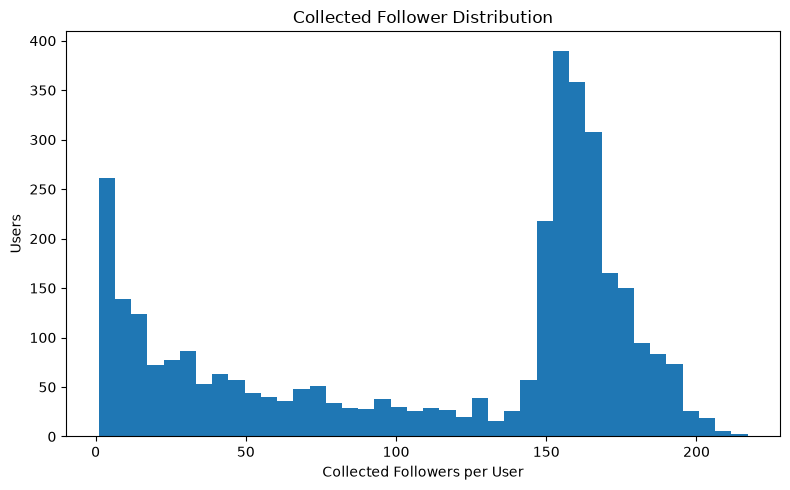

In [149]:
plt.figure(figsize=(8, 5))

plt.hist(
    graph_clean["collected_followers_count"],
    bins=40
)

plt.xlabel("Collected Followers per User")
plt.ylabel("Users")
plt.title("Collected Follower Distribution")

plt.tight_layout()
plt.show()

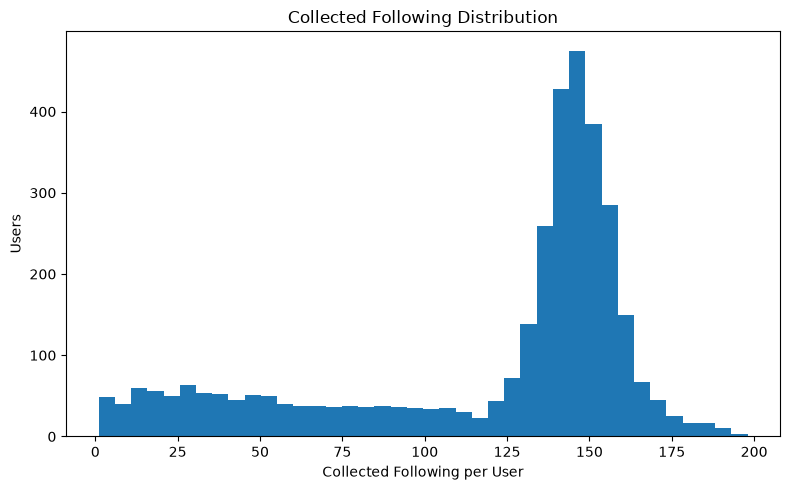

In [150]:
plt.figure(figsize=(8, 5))

plt.hist(
    graph_clean["collected_following_count"],
    bins=40
)

plt.xlabel("Collected Following per User")
plt.ylabel("Users")
plt.title("Collected Following Distribution")

plt.tight_layout()
plt.show()

In [151]:
edges = []

for _, row in graph_clean.iterrows():
    
    user = row["screen_name"]    
    
    # People who follow this user:
    # follower -> user
    
    for follower in row["followers_list"]:
        if follower != user:
            edges.append(
                (
                    follower,
                    user,
                    "follows"
                )
            )
    
    # Accounts followed by this user:
    # user -> following
    
    for followed in row["following_list"]:
        
        if followed != user:
            edges.append(
                (
                    user,
                    followed,
                    "follows"
                )
            )

edge_df = pd.DataFrame(
    edges,
    columns=[
        "source",
        "target",
        "relation"
    ]
)

print("Raw edges:", len(edge_df))
display(edge_df.head())

Raw edges: 800207


,source,target,relation
0,chaiiee,SajjadSade48567,follows
1,dr_lizzii,SajjadSade48567,follows
2,nathaniel2026,SajjadSade48567,follows
3,julian270zi,SajjadSade48567,follows
4,kongoshadha,SajjadSade48567,follows


In [152]:
before = len(edge_df)
edge_df = (
    edge_df[
        edge_df["source"] !=
        edge_df["target"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Edges before cleaning:", before)
print("Edges after cleaning:", len(edge_df))
print("Removed:", before - len(edge_df))

Edges before cleaning: 800207
Edges after cleaning: 796485
Removed: 3722


In [153]:
graph_nodes = set(
    edge_df["source"]
).union(
    set(edge_df["target"])
)

n_nodes = len(graph_nodes)
n_edges = len(edge_df)

print("Graph nodes:", n_nodes)
print("Graph edges:", n_edges)

if n_nodes > 1:
    
    density = (
        n_edges /
        (n_nodes * (n_nodes - 1))
    )
    
    print(
        "Directed graph density:",
        density
    )

Graph nodes: 230806
Graph edges: 796485
Directed graph density: 1.4951518203525365e-05


In [154]:
out_degree = (
    edge_df
    .groupby("source")
    .size()
    .rename("out_degree")
)

in_degree = (
    edge_df
    .groupby("target")
    .size()
    .rename("in_degree")
)

degree_df = pd.concat(
    [
        in_degree,
        out_degree
    ],
    axis=1
).fillna(0)

degree_df["total_degree"] = (
    degree_df["in_degree"] +
    degree_df["out_degree"]
)

display(
    degree_df.describe()
)

,in_degree,out_degree,total_degree
count,230806.000000,230806.000000,230806.000000
mean,3.450885,3.450885,6.901770
std,21.673729,17.666319,37.051689
min,0.000000,0.000000,1.000000
25%,0.000000,0.000000,1.000000
50%,0.000000,1.000000,1.000000
75%,1.000000,1.000000,2.000000
max,1664.000000,616.000000,1665.000000


In [155]:
display(
    degree_df
    .sort_values(
        "total_degree",
        ascending=False
    )
    .head(20)
)

,in_degree,out_degree,total_degree
PahlaviComms,1664.0,1.0,1665.0
PahlaviReza,1430.0,75.0,1505.0
IsraelPersian,1043.0,129.0,1172.0
yYh8x5hC6nxh1Wd,570.0,473.0,1043.0
alikarimi_ak8,1040.0,0.0,1040.0
Ario1401,815.0,185.0,1000.0
ShahbanouFarah,993.0,0.0,993.0
Dokhi_sag,344.0,616.0,960.0
masoudcastel,440.0,487.0,927.0
shayan_shahnazi,692.0,207.0,899.0


In [156]:
all_dataset_users = (
    labeled_names |
    unlabeled_names
)

edge_df["source_in_dataset"] = (
    edge_df["source"]
    .isin(all_dataset_users)
)

edge_df["target_in_dataset"] = (
    edge_df["target"]
    .isin(all_dataset_users)
)

edge_df["internal_edge"] = (
    edge_df["source_in_dataset"] &
    edge_df["target_in_dataset"]
)

print(
    "Total edges:",
    len(edge_df)
)

print(
    "Edges with both endpoints in our datasets:",
    edge_df["internal_edge"].sum()
)

print(
    "Internal edge percentage:",
    round(
        edge_df["internal_edge"].mean()
        * 100,
        2
    ),
    "%"
)

Total edges: 796485
Edges with both endpoints in our datasets: 284743
Internal edge percentage: 35.75 %


In [157]:
graph_class_df = users_1k[
    ["screen_name", LABEL_COL]
].copy()

graph_class_df["has_graph"] = (
    graph_class_df["screen_name"]
    .isin(graph_names)
)

graph_coverage_by_class = (
    graph_class_df
    .groupby(LABEL_COL)["has_graph"]
    .agg(["count", "sum", "mean"])
)

graph_coverage_by_class["coverage_percent"] = (
    graph_coverage_by_class["mean"]
    * 100
)

display(
    graph_coverage_by_class
)

,count,sum,mean,coverage_percent
برچسب نهایی,,,,
News Agent(3),29,16,0.551724,55.172414
bot(1),187,44,0.235294,23.529412
can’t find,58,18,0.310345,31.034483
human(2),772,231,0.299223,29.922280
unverified(4),57,15,0.263158,26.315789


In [158]:
audit_1k = users_1k[
    [
        "screen_name",
        LABEL_COL
    ]
].copy()

audit_1k["has_profile"] = True

audit_1k["has_tweet"] = (
    audit_1k["screen_name"]
    .isin(tweet_names)
)

audit_1k["has_temporal"] = (
    users_1k[
        available_temporal
    ]
    .notna()
    .any(axis=1)
    .values
)

audit_1k["has_complete_temporal"] = (
    users_1k[
        available_temporal
    ]
    .notna()
    .all(axis=1)
    .values
)

audit_1k["has_graph"] = (
    audit_1k["screen_name"]
    .isin(graph_names)
)

display(audit_1k.head())

,screen_name,برچسب نهایی,has_profile,has_tweet,has_temporal,has_complete_temporal,has_graph
0,ahmad_313m,human(2),True,True,True,True,False
1,samsarbazvatan,bot(1),True,True,True,True,False
2,cryptosamz,human(2),True,True,True,True,True
3,sepiedhia,human(2),True,True,True,True,True
4,777Masiha,bot(1),True,True,False,False,False


In [159]:
def modality_pattern(row):
    
    available = ["Profile"]
    
    if row["has_tweet"]:
        available.append("Tweet")
    
    if row["has_temporal"]:
        available.append("Temporal")
    
    if row["has_graph"]:
        available.append("Graph")
    
    return " + ".join(available)


audit_1k["modality_pattern"] = (
    audit_1k.apply(
        modality_pattern,
        axis=1
    )
)

modality_report = (
    audit_1k[
        "modality_pattern"
    ]
    .value_counts()
    .to_frame("users")
)

modality_report["percentage"] = (
    modality_report["users"]
    / len(audit_1k)
    * 100
)

display(
    modality_report.round(2)
)

,users,percentage
modality_pattern,,
Profile + Tweet + Temporal,620,56.21
Profile + Tweet + Temporal + Graph,266,24.12
Profile + Tweet,156,14.14
Profile + Tweet + Graph,57,5.17
Profile + Temporal,3,0.27
Profile + Temporal + Graph,1,0.09


In [160]:
audit_19k = users_19k[
    ["screen_name"]
].copy()

audit_19k["has_profile"] = True

# Raw tweet dataset is not available for the 19K pool
audit_19k["has_raw_tweet"] = (
    audit_19k["screen_name"]
    .isin(tweet_names)
)

temporal_19k = [
    c for c in temporal_behavior_features
    if c in users_19k.columns
]

audit_19k["has_temporal"] = (
    users_19k[
        temporal_19k
    ]
    .notna()
    .any(axis=1)
    .values
)

audit_19k["has_graph"] = (
    audit_19k["screen_name"]
    .isin(graph_names)
)

display(
    audit_19k[
        [
            "has_raw_tweet",
            "has_temporal",
            "has_graph"
        ]
    ]
    .mean()
    .mul(100)
    .rename("coverage_percent")
    .to_frame()
)

,coverage_percent
has_raw_tweet,5.627883
has_temporal,99.994874
has_graph,17.211686


In [161]:
for col in [
    "description",
    "clean_description"
]:
    
    if col in users_19k.columns:
        
        available = (
            users_19k[col]
            .notna()
            .sum()
        )
        
        print(
            col,
            ":",
            available,
            "/",
            len(users_19k),
            "=",
            round(
                available /
                len(users_19k) *
                100,
                2
            ),
            "%"
        )

description : 12699 / 19510 = 65.09 %
clean_description : 12527 / 19510 = 64.21 %


In [162]:
overlap_1k_19k = (
    labeled_names &
    unlabeled_names
)

print(
    "Users appearing in both 1K and 19K:",
    len(overlap_1k_19k)
)

print(
    "Percentage of labeled users also in 19K:",
    round(
        len(overlap_1k_19k)
        / len(labeled_names)
        * 100,
        2
    ),
    "%"
)

Users appearing in both 1K and 19K: 1102
Percentage of labeled users also in 19K: 99.91 %


In [163]:
pseudo_pool = users_19k[
    ~users_19k["screen_name"]
    .isin(labeled_names)
].copy()

print(
    "Original 19K pool:",
    len(users_19k)
)

print(
    "Overlap removed:",
    len(users_19k)
    - len(pseudo_pool)
)

print(
    "Final pseudo-label candidate pool:",
    len(pseudo_pool)
)

Original 19K pool: 19510
Overlap removed: 1102
Final pseudo-label candidate pool: 18408


In [164]:
possible_leakage_keywords = [
    "class",
    "برچسب",
    "LLM",
    "Grok",
    "tagger",
    "Probe",
    "Reason",
    "reason"
]

possible_leakage_columns = []

for col in users_1k.columns:
    
    col_str = str(col)
    
    if any(
        keyword.lower() in col_str.lower()
        for keyword in possible_leakage_keywords
    ):
        
        possible_leakage_columns.append(col)

print(
    "Potential leakage columns:"
)

for col in possible_leakage_columns:
    print("-", col)

Potential leakage columns:
- LLM(ChatGPT)
- LLM(Gemini)
- Grok 4
- class (1:bot, 2:human, 3:News Agent, 4:unverified)
- tagger's name 2
- Probe2
- class (1:bot, 2:human, 3:News Agent, 4:unverified)_1
- Reason2
- tagger's name 3
- Probe3
- class (1:bot, 2:human, 3:News Agent, 4:unverified)_2
- Reason3
- بیو حساب شامل اطلاعات شخصی است ( برای مثال اسم دانشگاه، مدرک تحصیلی ، نام محل کار و...) ( نیاز به بررسی دستی حساب ها یا استفاده از llm دارد)
- برچسب نهایی


In [165]:
def high_missing_columns(
    df,
    threshold=90
):
    
    pct = (
        df.isna()
        .mean()
        .mul(100)
    )
    
    return (
        pct[pct >= threshold]
        .sort_values(
            ascending=False
        )
    )


print("1K columns >= 90% missing")
display(
    high_missing_columns(
        users_1k
    ).to_frame("missing_percent")
)


print("\n19K columns >= 90% missing")
display(
    high_missing_columns(
        users_19k
    ).to_frame("missing_percent")
)

1K columns >= 90% missing


,missing_percent
Unnamed: 58,100.000000
Grok 4,100.000000
profile_interstitial_type,99.909338
تصویر پروفایل واقعی باشد ( نیاز به بررسی دستی حساب ها دارد),99.818676
LLM(Gemini),99.456029
verified_type,99.365367
آیا دنبال‌شوندگان/دنبال‌کننده‌ها غیرعادی‌اند؟نسبت غیرمنطقی، فالوورهای فیک (ویژگی‌های شبکه‌ای و تعاملات (Network Features)\nالگوهای ارتباطی و شبکه اجتماعی حساب‌ها:\n• نسبت فالوورها به فالووینگ:\no دنبال‌کردن هزاران نفر و داشتن تعداد کمی فالوور.\no یا برعکس: داشتن تعداد زیاد فالوور اما بدون تعامل واقعی.\n• خوشه‌های هماهنگ: چند حساب با هم توییت مشابه منتشر می‌کنند یا همزمان لایک/ری‌توئیت می‌کنند.\n• شبکه‌های مشابه: داشتن مجموعه‌ای مشابه از فالوورها یا فالووینگ‌ها.\n• Retweet farms: حساب‌هایی که صرفاً ری‌توئیت می‌کنند تا ترند مصنوعی بسازند.),98.912058
LLM(ChatGPT),96.373527
"آیا پروفایل واقعی به‌نظر می‌رسد؟عکس واقعی، بیوگرافی کامل، نام کاربری (\n• نام کاربری(username/handle):\no وجود رشته‌های عددی طولانی (user12345678)\no شباهت زیاد نام‌ها در چند حساب مختلف مثلاً iran_news01, iran_news02، ….\no نام‌هایی بی‌معنی یا تصادفی (abc_45_klo)\n• تصویر پروفایل:\no استفاده از تصویر پیش‌فرض یا avatar عمومی\no تصاویر دزدیده‌شده یا تکراری می‌توان با جستجوی معکوس گوگل بررسی کرد.\no کیفیت پایین یا غیرمرتبط (مثلاً لوگوی تصادفی).\n• بیو (Bio):\no بیوهای خالی یا خیلی کوتاه.\no بیوهای تکراری بین چند حساب (کپی/پیست).\no استفاده از کلمات کلیدی مثل bot, feed, auto، یا فقط هشتگ.\n• تاریخ ایجاد حساب:\no حساب‌های خیلی جدید که در همان روز/هفته صدها توییت می‌زنند.\no موجی از حساب‌های جدید در بازه زمانی کوتاه.\n• لینک‌ها در پروفایل:\no لینک‌های کوتاه‌شده (tinyurl) که مقصدشان تبلیغی یا مشکوک است.\no تکرار یک دامنه در پروفایل چند حساب مشابه.)",93.834995
"آیا تعامل با دیگران وجود دارد؟ریپلای، منشن، گفت‌وگو با کاربران (ویژگی‌های رفتاری در مکالمه (Conversational Features)\n• پاسخ‌دهی کم: حسابی که تقریباً هیچوقت جواب مستقیم نمی‌دهد.\n• پاسخ‌های ماشینی: جملات کلیشه‌ای و تکراری مثل ""Great post!"" یا ""Nice info""\n• تأخیر یکنواخت در پاسخ: مثلاً همیشه ۳ ثانیه بعد جواب می‌دهد.\n• نبود تعامل شخصی: اشاره نکردن به تجربیات فردی یا مکالمات واقعی.)",93.744334



19K columns >= 90% missing


,missing_percent
Grok 4,100.000000
reason 2,100.000000
profile_interstitial_type,99.974372
آیا دنبال‌شوندگان/دنبال‌کننده‌ها غیرعادی‌اند؟نسبت غیرمنطقی، فالوورهای فیک (ویژگی‌های شبکه‌ای و تعاملات (Network Features)\nالگوهای ارتباطی و شبکه اجتماعی حساب‌ها:\n• نسبت فالوورها به فالووینگ:\no دنبال‌کردن هزاران نفر و داشتن تعداد کمی فالوور.\no یا برعکس: داشتن تعداد زیاد فالوور اما بدون تعامل واقعی.\n• خوشه‌های هماهنگ: چند حساب با هم توییت مشابه منتشر می‌کنند یا همزمان لایک/ری‌توئیت می‌کنند.\n• شبکه‌های مشابه: داشتن مجموعه‌ای مشابه از فالوورها یا فالووینگ‌ها.\n• Retweet farms: حساب‌هایی که صرفاً ری‌توئیت می‌کنند تا ترند مصنوعی بسازند.),99.589954
verified_type,99.425935
LLM(Gemini),99.144029
LLM(ChatGPT),98.149667
prob 2,97.432086
tagger's name2,97.432086
"آیا پروفایل واقعی به‌نظر می‌رسد؟عکس واقعی، بیوگرافی کامل، نام کاربری (\n• نام کاربری(username/handle):\no وجود رشته‌های عددی طولانی (user12345678)\no شباهت زیاد نام‌ها در چند حساب مختلف مثلاً iran_news01, iran_news02، ….\no نام‌هایی بی‌معنی یا تصادفی (abc_45_klo)\n• تصویر پروفایل:\no استفاده از تصویر پیش‌فرض یا avatar عمومی\no تصاویر دزدیده‌شده یا تکراری می‌توان با جستجوی معکوس گوگل بررسی کرد.\no کیفیت پایین یا غیرمرتبط (مثلاً لوگوی تصادفی).\n• بیو (Bio):\no بیوهای خالی یا خیلی کوتاه.\no بیوهای تکراری بین چند حساب (کپی/پیست).\no استفاده از کلمات کلیدی مثل bot, feed, auto، یا فقط هشتگ.\n• تاریخ ایجاد حساب:\no حساب‌های خیلی جدید که در همان روز/هفته صدها توییت می‌زنند.\no موجی از حساب‌های جدید در بازه زمانی کوتاه.\n• لینک‌ها در پروفایل:\no لینک‌های کوتاه‌شده (tinyurl) که مقصدشان تبلیغی یا مشکوک است.\no تکرار یک دامنه در پروفایل چند حساب مشابه.)",97.196310


In [166]:
cols_1k = set(
    users_1k.columns
)

cols_19k = set(
    users_19k.columns
)

common_columns = sorted(
    cols_1k &
    cols_19k
)

only_1k = sorted(
    cols_1k -
    cols_19k
)

only_19k = sorted(
    cols_19k -
    cols_1k
)

print(
    "Common columns:",
    len(common_columns)
)

print(
    "Columns only in 1K:",
    len(only_1k)
)

print(
    "Columns only in 19K:",
    len(only_19k)
)

Common columns: 68
Columns only in 1K: 36
Columns only in 19K: 7


In [167]:
non_feature_columns = {
    "id",
    "screen_name",
    "name",
    "created_at",
    "last_updated",
    "برچسب نهایی"
}

common_model_candidates = [
    c for c in common_columns
    if c not in non_feature_columns
    and c not in possible_leakage_columns
]

print(
    "Number of common candidate features:",
    len(common_model_candidates)
)

print(common_model_candidates)

Number of common candidate features: 61
['Botometer Score', 'clean_description', 'cluster_id', 'default_profile', 'default_profile_image', 'description', 'fast_followers_count', 'favourites_count', 'follower_growth_rate', 'followers_count', 'following', 'friends_count', 'friends_growth_rate', 'has_custom_timelines', 'hashtag_in_description', 'is_translator', 'listed_count', 'location', 'max_occurence_of_same_gap', 'max_tweets_per_day', 'max_tweets_per_hour', 'mean_favourites_per_tweet', 'mean_no_hashtags', 'mean_no_media_per_tweet', 'mean_no_words', 'mean_retweets_per_tweet', 'mean_user_mentions_per_tweet', 'media_count', 'min_tweets_per_day', 'min_tweets_per_hour', 'no_languages', 'no_retweet_tweets', 'no_type_reply', 'no_type_retweet_with_comment', 'no_type_tweet', 'normal_followers_count', 'numbers_in_description', 'pinned_tweet_ids_str', 'possibly_sensitive', 'profile_banner_url', 'profile_image_url_https', 'profile_interstitial_type', 'retweet_as_tweet_rate', 'status_count', 'stat

In [168]:
summary = pd.DataFrame({

    "Dataset": [
        "Labeled Users",
        "Unlabeled Users",
        "Tweet Records",
        "Graph User Records"
    ],

    "Rows": [
        len(users_1k),
        len(users_19k),
        len(tweets_df),
        len(graph_df)
    ],

    "Columns": [
        users_1k.shape[1],
        users_19k.shape[1],
        tweets_df.shape[1],
        graph_df.shape[1]
    ]
})

display(summary)

,Dataset,Rows,Columns
0,Labeled Users,1103,104
1,Unlabeled Users,19510,75
2,Tweet Records,75913,40
3,Graph User Records,3453,4


In [169]:
OUTPUT_DIR = "../processed_data/phase1-audit"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

audit_1k.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "labeled_modality_audit.csv"
    ),
    index=False
)

audit_19k.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "unlabeled_modality_audit.csv"
    ),
    index=False
)

tweet_count.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tweet_count_per_user.csv"
    ),
    index=False
)

tweet_user_stats.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tweet_user_statistics.csv"
    ),
    index=False
)

graph_clean.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "graph_user_statistics.csv"
    ),
    index=False
)

edge_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "graph_edges.csv"
    ),
    index=False
)

pseudo_pool.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "unlabeled_pseudo_label_pool.csv"
    ),
    index=False
)

print("All audit outputs were saved successfully.")

All audit outputs were saved successfully.


## Dataset Audit Summary

The exploratory analysis revealed several important characteristics of the datasets:

- The labeled dataset contains 1,103 users and is highly class-imbalanced.
- Human accounts form the majority of the labeled dataset.
- Raw tweet data are available for approximately 99.6% of labeled users.
- The tweet dataset contains text, language, temporal and engagement information.
- Social graph information is available only for a subset of users.
- Therefore, the graph modality cannot be treated as a mandatory input.
- The unlabeled 19K dataset does not contain a corresponding complete raw tweet corpus,
  although aggregated behavioral features and profile descriptions are available.
- A missing-modality-aware multimodal architecture is therefore required.
- Potential label-leakage columns, including LLM/tagger outputs and manually generated
  labels, must not be used as predictive input features.
- The large Twitter identifiers should not be matched as floating-point numbers;
  screen_name is used as the current cross-dataset matching key.
- Users shared between the labeled and unlabeled pools must be removed from the
  pseudo-labeling pool to prevent data leakage.
- The next stage will perform preprocessing, feature selection, scaling,
  text preprocessing and model-ready dataset construction.